# **Лабораторна робота №2 “Пошук асоціативних правил”**

<p>Виконала студентка ІІ-го курсу</p>
<p>Басовська Марія, групи КН-43</p>

---

<font size="5">**Мета**</font>

Ознайомитися з принципами побудови асоціативних правил (association rule mining) на реальних даних користувацьких уподобань. Навчитись виконувати пошук частих наборів елементів (frequent itemsets) і формувати асоціативні правила за допомогою метрик support, confidence і lift на основі набору даних MovieLens Small. Розвинути навички попередньої обробки даних, перетворення даних у транзакційний формат і інтерпретації результатів.

---

<font size="5">**Інструменти**</font>

Python: pandas, numpy, matplotlib, plotly, mlxtend.frequent_patterns; Jupyter Notebook

---

<font size="5">**Хід роботи**</font>

<font size="4">**1.Завантаження та підготовка даних**</font>



In [1]:
import os
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings("ignore") 
import matplotlib.pyplot as plt
import seaborn as sns

ratings = pd.read_csv(r'C:\Users\irgtb\Downloads\ml-latest-small\ml-latest-small\ratings.csv')
movies = pd.read_csv(r'C:\Users\irgtb\Downloads\ml-latest-small\ml-latest-small\movies.csv')

data = ratings.merge(movies, on='movieId')

data['rating'] = data['rating'].astype(float)
data_liked = data[data['rating'] >= 4.0]

basket = data_liked.pivot_table(index='userId', 
                                columns='title', 
                                values='rating', 
                                aggfunc='max', 
                                fill_value=0)
basket = (basket >= 4).astype(int) 

print("Розмір таблиці:", data_liked.shape)
print("Кількість унікальних користувачів:", data_liked['userId'].nunique())
print("Кількість унікальних фільмів:", data_liked['movieId'].nunique())

Розмір таблиці: (48580, 6)
Кількість унікальних користувачів: 609
Кількість унікальних фільмів: 6298


<font size="4">**2.Перетворення даних у транзакційний формат**</font>

In [2]:
basket_sample = basket.iloc[:10]  

basket_sample = basket_sample.loc[:, basket_sample.sum(axis=0) > 0]

basket_sample

title,12 Angry Men (1957),"13th Warrior, The (1999)",20 Dates (1998),2001: A Space Odyssey (1968),A.I. Artificial Intelligence (2001),About Time (2013),"Abyss, The (1989)",Adaptation (2002),"Adventures of Priscilla, Queen of the Desert, The (1994)","Adventures of Robin Hood, The (1938)",...,Witness (1985),"Wizard of Oz, The (1939)","Wolf Man, The (1941)","Wolf of Wall Street, The (2013)",Wonder Boys (2000),X-Men (2000),X-Men: The Last Stand (2006),X2: X-Men United (2003),Young Frankenstein (1974),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,0,1,1,0,0,0,1,0,0,1,...,0,1,1,0,0,1,0,0,1,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,1,0,...,0,1,0,0,1,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0


<font size="4">**3.Пошук частих наборів фільмів**</font>

In [3]:
from mlxtend.frequent_patterns import apriori

min_support_values = [0.05, 0.1, 0.3]

for min_sup in min_support_values:
    frequent_itemsets = apriori(basket, min_support=min_sup, use_colnames=True)
    
    print(f"\nmin_support = {min_sup}")
    print(f"Кількість частих наборів: {len(frequent_itemsets)}")
    
    top10 = frequent_itemsets.sort_values('support', ascending=False).head(10)
    print("Топ-10 комбінацій:")
    display(top10)


min_support = 0.05
Кількість частих наборів: 33189
Топ-10 комбінацій:


,support,itemsets
267,0.449918,"(Shawshank Redemption, The (1994))"
119,0.408867,(Forrest Gump (1994))
244,0.400657,(Pulp Fiction (1994))
273,0.369458,"(Silence of the Lambs, The (1991))"
206,0.364532,"(Matrix, The (1999))"
299,0.330049,(Star Wars: Episode IV - A New Hope (1977))
115,0.293924,(Fight Club (1999))
260,0.287356,(Schindler's List (1993))
2228,0.275862,"(Forrest Gump (1994), Shawshank Redemption, Th..."
300,0.275862,(Star Wars: Episode V - The Empire Strikes Bac...



min_support = 0.1
Кількість частих наборів: 863
Топ-10 комбінацій:


,support,itemsets
93,0.449918,"(Shawshank Redemption, The (1994))"
40,0.408867,(Forrest Gump (1994))
83,0.400657,(Pulp Fiction (1994))
96,0.369458,"(Silence of the Lambs, The (1991))"
68,0.364532,"(Matrix, The (1999))"
103,0.330049,(Star Wars: Episode IV - A New Hope (1977))
38,0.293924,(Fight Club (1999))
90,0.287356,(Schindler's List (1993))
279,0.275862,"(Forrest Gump (1994), Shawshank Redemption, Th..."
104,0.275862,(Star Wars: Episode V - The Empire Strikes Bac...



min_support = 0.3
Кількість частих наборів: 6
Топ-10 комбінацій:


,support,itemsets
3,0.449918,"(Shawshank Redemption, The (1994))"
0,0.408867,(Forrest Gump (1994))
2,0.400657,(Pulp Fiction (1994))
4,0.369458,"(Silence of the Lambs, The (1991))"
1,0.364532,"(Matrix, The (1999))"
5,0.330049,(Star Wars: Episode IV - A New Hope (1977))


<font size="4">**4.Побудова асоціативних правил**</font>


Топ-10 асоціативних правил за lift:


,antecedents,consequents,support,confidence,lift
463826,"(Kill Bill: Vol. 2 (2004), Star Wars: Episode ...","(Star Wars: Episode IV - A New Hope (1977), Ki...",0.052545,0.888889,13.203252
463807,"(Star Wars: Episode IV - A New Hope (1977), Ki...","(Kill Bill: Vol. 2 (2004), Star Wars: Episode ...",0.052545,0.780488,13.203252
463793,"(Star Wars: Episode IV - A New Hope (1977), Ki...","(Kill Bill: Vol. 2 (2004), Star Wars: Episode ...",0.052545,0.864865,12.846407
463798,"(Kill Bill: Vol. 2 (2004), Star Wars: Episode ...",(Star Wars: Episode VI - Return of the Jedi (1...,0.052545,0.864865,12.846407
463840,"(Kill Bill: Vol. 2 (2004), Star Wars: Episode ...","(Star Wars: Episode IV - A New Hope (1977), Ki...",0.052545,0.780488,12.846407
463835,(Star Wars: Episode VI - Return of the Jedi (1...,"(Kill Bill: Vol. 2 (2004), Star Wars: Episode ...",0.052545,0.780488,12.846407
463832,"(Kill Bill: Vol. 1 (2003), Star Wars: Episode ...","(Kill Bill: Vol. 2 (2004), Star Wars: Episode ...",0.052545,0.695652,12.837945
463801,"(Kill Bill: Vol. 2 (2004), Star Wars: Episode ...","(Kill Bill: Vol. 1 (2003), Star Wars: Episode ...",0.052545,0.969697,12.837945
463819,(Star Wars: Episode VI - Return of the Jedi (1...,"(Kill Bill: Vol. 2 (2004), Star Wars: Episode ...",0.052545,0.800000,12.821053
463814,"(Kill Bill: Vol. 2 (2004), Star Wars: Episode ...",(Star Wars: Episode VI - Return of the Jedi (1...,0.052545,0.842105,12.821053


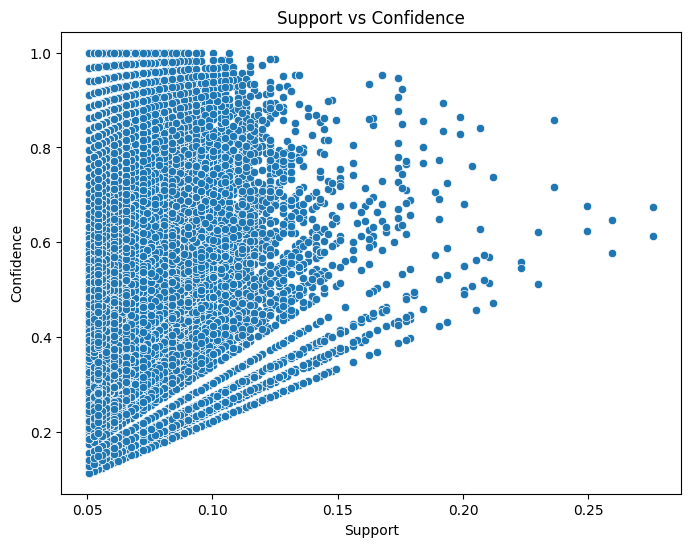

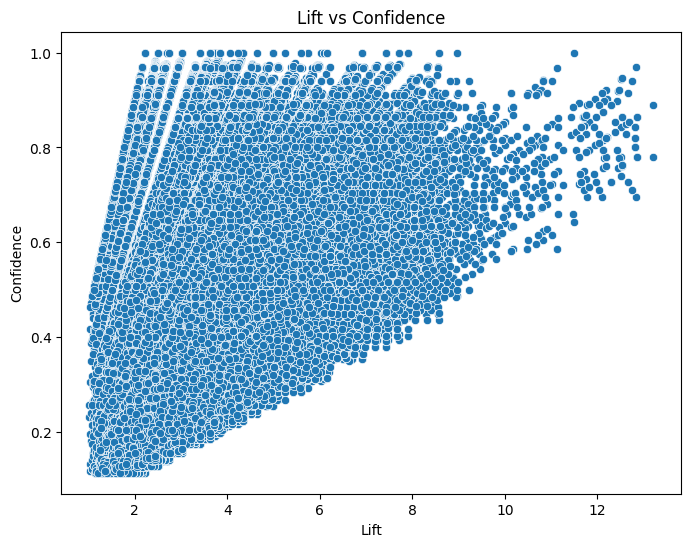

In [4]:
frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

top_rules = rules.sort_values('lift', ascending=False).head(10)
print("\nТоп-10 асоціативних правил за lift:")
display(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

plt.figure(figsize=(8,6))
sns.scatterplot(x='support', y='confidence', data=rules)
plt.title('Support vs Confidence')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x='lift', y='confidence', data=rules)
plt.title('Lift vs Confidence')
plt.xlabel('Lift')
plt.ylabel('Confidence')
plt.show()

<font size="4">**5.Аналіз та висновки**</font>

Асоціативні правила є ефективним інструментом для побудови систем рекомендацій, оскільки дозволяють виявляти приховані закономірності у вподобаннях користувачів. На основі таких правил можна робити прості та зрозумілі рекомендації: якщо користувачеві сподобався певний фільм або набір фільмів, система може запропонувати інші фільми, які часто зустрічаються разом із ними в історії оцінок інших користувачів. Такий підхід широко використовується у сервісах потокового відео, інтернет-магазинах та музичних платформах, оскільки він не потребує складних моделей і добре працює навіть без глибокої персоналізації.

Параметри min_support і min_confidence суттєво впливають на результати аналізу. Значення min_support визначає, наскільки часто певна комбінація елементів повинна зустрічатися в даних, щоб вважатися значущою. При високому значенні цього параметра знаходяться лише найпопулярніші та найнадійніші набори, але їх кількість є невеликою, і вони часто відображають лише загальні тенденції. При зниженні min_support кількість знайдених наборів значно зростає, що дозволяє виявити менш очевидні, але потенційно цікаві зв’язки, проте серед них може бути більше випадкових або малозначущих комбінацій.

Параметр min_confidence визначає силу залежності між елементами у правилі. Високий рівень confidence означає, що правило є більш надійним і з більшою ймовірністю спрацює у рекомендації, але це також зменшує кількість доступних правил. Низький рівень confidence дозволяє отримати більше правил, проте вони можуть бути слабшими і менш корисними на практиці.

Отже, вибір значень min_support і min_confidence є компромісом між кількістю та якістю правил. Для практичних систем рекомендацій важливо знайти баланс: отримати достатню кількість правил для покриття різних сценаріїв, але водночас забезпечити їхню інформативність і надійність.